In [37]:
# ==============================
# 1. 라이브러리 불러오기
# ==============================
import os
import glob
import shutil
import kagglehub
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [38]:
# ==============================
# 2. 데이터 다운로드
# ==============================
# KaggleHub로 데이터셋 다운로드
path = kagglehub.dataset_download("carlosrunner/pizza-not-pizza")
print("데이터 다운로드 경로:", path)

# 실제 이미지 폴더 경로 (pizza_not_pizza 내부)
pizza_dir = os.path.join(path, "pizza_not_pizza", "pizza")
not_pizza_dir = os.path.join(path, "pizza_not_pizza", "not_pizza")

데이터 다운로드 경로: C:\Users\pc\.cache\kagglehub\datasets\carlosrunner\pizza-not-pizza\versions\1


In [39]:
# ==============================
# 3. Train/Test 폴더 생성 및 데이터 분할
# ==============================
# 이미지 경로 리스트 생성
pizza_images = glob.glob(os.path.join(pizza_dir, "*.jpg"))
not_pizza_images = glob.glob(os.path.join(not_pizza_dir, "*.jpg"))

# Train/Test 분할 (80:20)
pizza_train, pizza_test = train_test_split(pizza_images, test_size=0.2, random_state=100)
not_pizza_train, not_pizza_test = train_test_split(not_pizza_images, test_size=0.2, random_state=100)

# 새로운 폴더 구조
base_dir = os.path.join(path, "split_data")
for folder in ["train/pizza", "train/not_pizza", "test/pizza", "test/not_pizza"]:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

# 이미지 복사
for img in pizza_train:
    shutil.copy(img, os.path.join(base_dir, "train/pizza"))
for img in pizza_test:
    shutil.copy(img, os.path.join(base_dir, "test/pizza"))
for img in not_pizza_train:
    shutil.copy(img, os.path.join(base_dir, "train/not_pizza"))
for img in not_pizza_test:
    shutil.copy(img, os.path.join(base_dir, "test/not_pizza"))

print("Train/Test 데이터 분할 완료")

Train/Test 데이터 분할 완료


In [40]:
# ==============================
# 4. ImageDataGenerator로 이미지 불러오기
# ==============================
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1572 images belonging to 2 classes.
Found 394 images belonging to 2 classes.


In [41]:
# ==============================
# 5. CNN 모델 정의
# ==============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

C:\Users\pc\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
# ==============================
# 6. 모델 컴파일
# ==============================
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [43]:
# ==============================
# 7. 학습 실행
# ==============================
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

C:\Users\pc\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 281ms/step - accuracy: 0.5375 - loss: 0.8227 - val_accuracy: 0.5812 - val_loss: 0.6748
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.6215 - loss: 0.6489 - val_accuracy: 0.7462 - val_loss: 0.5743
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.7067 - loss: 0.5644 - val_accuracy: 0.7208 - val_loss: 0.5647
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.7780 - loss: 0.4703 - val_accuracy: 0.7665 - val_loss: 0.5140
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.8289 - loss: 0.3852 - val_accuracy: 0.7056 - val_loss: 0.5715
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 275ms/step - accuracy: 0.8372 - loss: 0.3621 - val_accuracy: 0.7234 - val_loss: 0.6220
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 277ms/step - accuracy: 0.8963 - loss: 0.2582 - val_accuracy: 0.6904 - val_loss: 0.6728
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.9268 - loss: 0.2019 - val_accu

In [44]:
# ==============================
# 8. 성능 평가
# ==============================
# 예측 확률
y_pred_prob = model.predict(test_generator)
# 0.5 기준으로 클래스 변환
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_generator.classes

# 지표 계산
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc = roc_auc_score(y_true, y_pred_prob)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("ROC-AUC:", roc)
print("\nClassification Report:\n", classification_report(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step
Accuracy: 0.7538071065989848
F1 Score: 0.7440633245382586
ROC-AUC: 0.8074158056121002

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       197
           1       0.77      0.72      0.74       197

    accuracy                           0.75       394
   macro avg       0.76      0.75      0.75       394
weighted avg       0.76      0.75      0.75       394



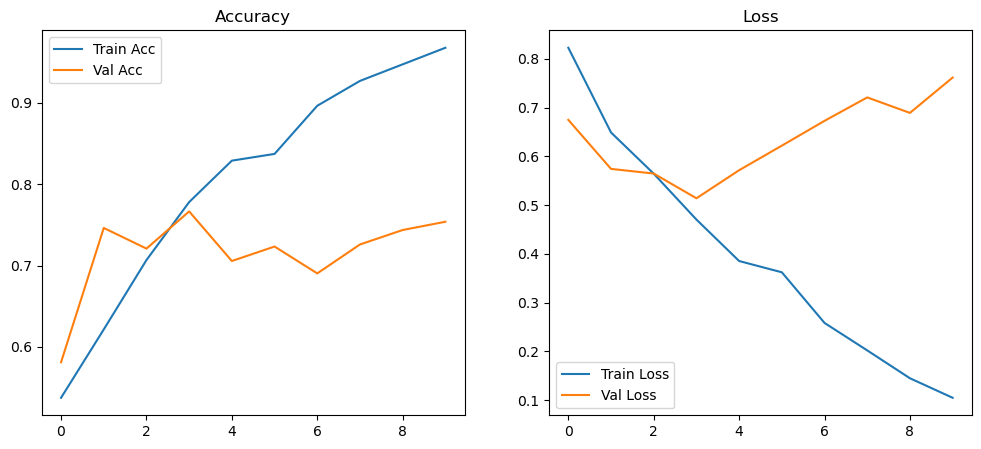

In [45]:
# ==============================
# 9. 학습 곡선 시각화
# ==============================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

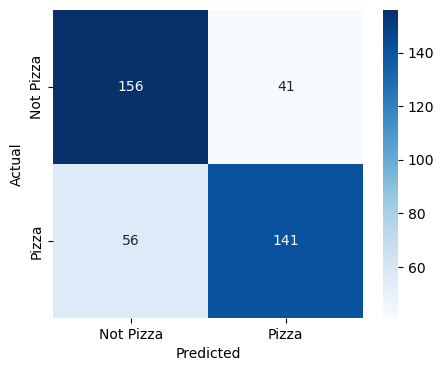

In [46]:
# ==============================
# 10. Confusion Matrix 시각화
# ==============================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Pizza','Pizza'], yticklabels=['Not Pizza','Pizza'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [47]:
!jupyter nbconvert --to script 백인호3번문제.ipynb

[NbConvertApp] Converting notebook 백인호3번문제.ipynb to script
[NbConvertApp] Writing 4916 bytes to 백인호3번문제.py
